In [51]:
import tensorflow as tf
import os, datetime
import tensorflow_recommenders as tfrs
from google.cloud import bigquery
import numpy as np
import pandas as pd
import pprint
from typing import Dict, Text

In [59]:
# Define the BigQuery table and project details
PROJECT_ID = 'oolola'
DATASET_ID = 'movie_data'
TABLE_ID = 'preprocessed_data'
# Load data from BigQuery
# def load_ratings_data_from_bigquery():
#     client = bigquery.Client(project=PROJECT_ID)
#     query = f"""
#     SELECT userId, title, movieId, rating
#     FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
#     """
#     query_job = client.query(query)
#     return query_job.to_dataframe()
def load_data_bq():
    client = bigquery.Client(project=PROJECT_ID)
    query = f"""
    SELECT userId, title, movieId, rating
    FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
    LIMIT 1000000
    """
    query_job = client.query(query)
    return query_job.to_dataframe()

In [53]:
def load_movies_data_from_bigquery():
    client = bigquery.Client(project=PROJECT_ID)
    query = f"""
    SELECT title, movieId, genres
    FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
    """
    query_job = client.query(query)
    return query_job.to_dataframe()

In [60]:
# Convert the genres column to a list of tensors
bq_data = load_data_bq()
# bq_ratings_data = load_ratings_data_from_bigquery()
# bq_movies_data = load_movies_data_from_bigquery()

In [61]:
# # Convert the DataFrame to a dictionary of lists
ratings_dict = {key: list(value) for key, value in bq_data[['title', 'userId']].to_dict(orient='list').items()}
# Create the TensorFlow dataset
ratings = tf.data.Dataset.from_tensor_slices(ratings_dict)

In [63]:
for x in ratings.take(1).as_numpy_iterator():
  pprint.pprint(x)

{'title': b'9 (2005)', 'userId': 144844}


In [65]:
movies_dict = {key: list(value) for key, value in bq_data[['title']].to_dict(orient='list').items()}
movies = tf.data.Dataset.from_tensor_slices(movies_dict)

In [66]:
for x in movies.take(1).as_numpy_iterator():
  pprint.pprint(x)

{'title': b'9 (2005)'}


In [32]:
# If you want to use tfds.load to load the data, you can use the following code
# Ratings data.
# ratings = tfds.load("movielens/100k-ratings", split="train")
# # Features of all the available movies.
# movies = tfds.load("movielens/100k-movies", split="train")

Dl Completed...: 0 url [00:00, ? url/s]
Dl Completed...: 100%|██████████| 1/1 [00:01<00:00,  1.48 url/s]

Dl Completed...: 100%|██████████| 1/1 [00:01<00:00,  1.48 url/s]

Dl Completed...: 100%|██████████| 1/1 [00:01<00:00,  1.48 url/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]WARNING:absl:`TensorInfo.dtype` is deprecated. Please change your code to use NumPy with the field `TensorInfo.np_dtype` or use TensorFlow with the field `TensorInfo.tf_dtype`.


Dataset movielens downloaded and prepared to /Users/dmmckinn/tensorflow_datasets/movielens/100k-ratings/0.1.1. Subsequent calls will reuse this data.


Dl Completed...: 0 url [00:00, ? url/s]
Dl Completed...: 100%|██████████| 1/1 [00:00<00:00, 40.37 url/s]
Extraction completed...: 0 file [00:00, ? file/s]
Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]WARNING:absl:`TensorInfo.dtype` is deprecated. Please change your code to use NumPy with the field `TensorInfo.np_dtype` or use TensorFlow with the field `TensorInfo.tf_dtype`.


Dataset movielens downloaded and prepared to /Users/dmmckinn/tensorflow_datasets/movielens/100k-movies/0.1.1. Subsequent calls will reuse this data.


In [67]:
ratings = ratings.map(lambda x: {
    "title": x["title"],
    "userId": x["userId"],
})
movies = movies.map(lambda x: x["title"])

# ratings = ratings.map(lambda x: {
#     "movie_title": x["movie_title"],
#     "user_id": x["user_id"],
# })
# movies = movies.map(lambda x: x["movie_title"])

In [68]:
tf.random.set_seed(42)
shuffled = ratings.shuffle(100000, seed=42, reshuffle_each_iteration=False)

train = shuffled.take(80000)
test = shuffled.skip(80000).take(20000)

In [69]:
movie_titles = movies.batch(100000)
user_ids = ratings.batch(1000000).map(lambda x: x["userId"])

unique_movie_titles = np.unique(np.concatenate(list(movie_titles)))
unique_user_ids = np.unique(np.concatenate(list(user_ids)))

# unique_movie_titles_tensor = tf.convert_to_tensor(unique_movie_titles, dtype=tf.string)
# unique_user_ids_tensor = tf.convert_to_tensor(unique_user_ids, dtype=tf.int32)
# unique_movie_data = tf.data.Dataset.from_tensor_slices(unique_movie_titles)

# unique_movie_titles_tensor[:10]
# unique_user_ids_tensor[:10]
# unique_movie_titles[:10]

In [70]:
embedding_dimension = 32

In [71]:
user_model = tf.keras.Sequential([
  tf.keras.layers.IntegerLookup(
      vocabulary=unique_user_ids, mask_token=None),
  # We add an additional embedding to account for unknown tokens.
  tf.keras.layers.Embedding(len(unique_user_ids) + 1, embedding_dimension)
])
# user_model = tf.keras.Sequential([
#   tf.keras.layers.StringLookup(
#       vocabulary=unique_user_ids, mask_token=None),
#   # We add an additional embedding to account for unknown tokens.
#   tf.keras.layers.Embedding(len(unique_user_ids) + 1, embedding_dimension)
# ])


In [72]:
movie_model = tf.keras.Sequential([
  tf.keras.layers.StringLookup(
      vocabulary=unique_movie_titles, mask_token=None),
  tf.keras.layers.Embedding(len(unique_movie_titles) + 1, embedding_dimension)
])

In [73]:
for movie in movies.take(5):
    print(movie, movie.shape)


tf.Tensor(b'9 (2005)', shape=(), dtype=string) ()
tf.Tensor(b'9 (2005)', shape=(), dtype=string) ()
tf.Tensor(b'M (1931)', shape=(), dtype=string) ()
tf.Tensor(b'O (2001)', shape=(), dtype=string) ()
tf.Tensor(b'10 (1979)', shape=(), dtype=string) ()


In [74]:
metrics = tfrs.metrics.FactorizedTopK(
  candidates=movies.batch(128).map(movie_model)
)
metrics._candidates

In [75]:
task = tfrs.tasks.Retrieval(
  metrics=metrics
)

In [76]:
# Define the embedding dimension

class RecommendationModel(tfrs.Model):

  def __init__(self, user_model, movie_model):
    super().__init__()
    self.movie_model: tf.keras.Model = movie_model
    self.user_model: tf.keras.Model = user_model
    self.task: tf.keras.layers.Layer = task
    
  def compute_loss(self, features: Dict[Text, tf.Tensor], training=False) -> tf.Tensor:
    # We pick out the user features and pass them into the user model.
    user_embeddings = self.user_model(features["userId"])
    # And pick out the movie features and pass them into the movie model,
    # getting embeddings back.
    positive_movie_embeddings = self.movie_model(features["title"])

    # The task computes the loss and the metrics.
    return self.task(user_embeddings, positive_movie_embeddings)

In [77]:
# Instantiate and compile the model
model = RecommendationModel(user_model, movie_model)
model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.1))

# Prepare the data for training
cached_train = train.shuffle(10000).batch(8192).cache()
cached_test = test.batch(4096).cache()

In [ ]:
# Train the model
# TensorBoard logging
logdir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

# Additional callbacks for optimization
# checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
#     filepath=os.path.join(logdir, "best_model.tf"),
#     save_best_only=True,
#     monitor='factorized_top_k/top_1_categorical_accuracy',
#     mode='min'
# )
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='factorized_top_k/top_1_categorical_accuracy',
    patience=10,
    restore_best_weights=True
)

# Train the model

history = model.fit(
    cached_train,
    epochs=3,
)

Epoch 1/3
 1/10 [==>...........................] - ETA: 26:39 - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_5_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_10_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_50_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_100_categorical_accuracy: 0.0000e+00 - loss: 73817.0312 - regularization_loss: 0.0000e+00 - total_loss: 73817.0312

<Figure size 1000x500 with 0 Axes>

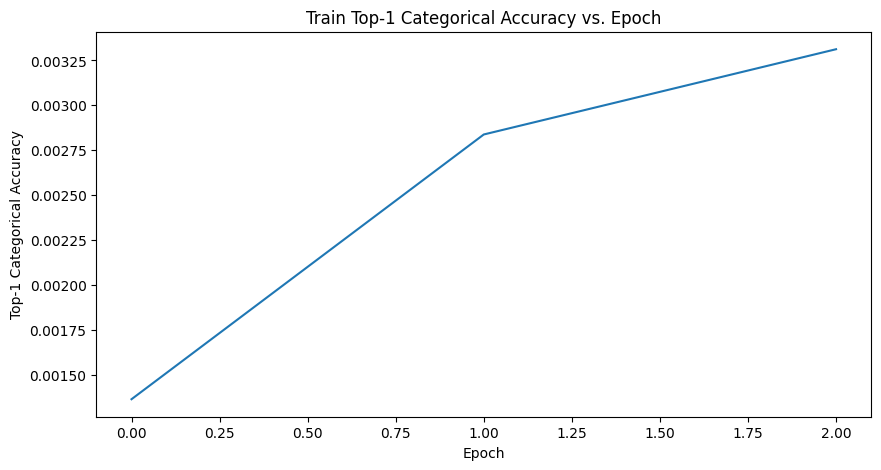

KeyError: 'val_factorized_top_k/top_1_categorical_accuracy'

<Figure size 1000x500 with 0 Axes>

In [ ]:
# Plot
import matplotlib.pyplot as plt
nrows = 1
ncols = 2
fig = plt.figure(figsize=(10, 5))

plt.figure(figsize=(10, 5))
plt.plot(history.history['factorized_top_k/top_1_categorical_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Top-1 Categorical Accuracy')
plt.title('Train Top-1 Categorical Accuracy vs. Epoch')
plt.show()

# Plot validation factorized_top_k/top_1_categorical_accuracy vs epoch
plt.figure(figsize=(10, 5))
plt.plot(history.history['val_factorized_top_k/top_1_categorical_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Top-1 Categorical Accuracy')
plt.title('Validation Top-1 Categorical Accuracy vs. Epoch')
plt.show()

In [ ]:
model.evaluate(cached_test, return_dict=True)

5/5 [==============================] - 4s 409ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0014 - factorized_top_k/top_5_categorical_accuracy: 0.0099 - factorized_top_k/top_10_categorical_accuracy: 0.0217 - factorized_top_k/top_50_categorical_accuracy: 0.1236 - factorized_top_k/top_100_categorical_accuracy: 0.2335 - loss: 31093.5729 - regularization_loss: 0.0000e+00 - total_loss: 31093.5729


{'factorized_top_k/top_1_categorical_accuracy': 0.00139999995008111,
 'factorized_top_k/top_5_categorical_accuracy': 0.009949999861419201,
 'factorized_top_k/top_10_categorical_accuracy': 0.021700000390410423,
 'factorized_top_k/top_50_categorical_accuracy': 0.12359999865293503,
 'factorized_top_k/top_100_categorical_accuracy': 0.23350000381469727,
 'loss': 28262.76171875,
 'regularization_loss': 0,
 'total_loss': 28262.76171875}

In [50]:
# Create a model that takes in raw query features, and
index = tfrs.layers.factorized_top_k.BruteForce(model.user_model)
# recommends movies out of the entire movies dataset.
index.index_from_dataset(
  tf.data.Dataset.zip((movies.batch(100), movies.batch(100).map(model.movie_model)))
)

# Get recommendations.
_, titles = index(tf.constant([97973]))
print(f"Recommendations for user 97973: {titles[0, :3]}")

Recommendations for user 90: [b'Kim (1950)' b'Hear My Song (1991)' b'Picnic (1955)']
